# Task43 EZmock 红移空间手动调参

本 notebook 从已经标定好的 real-space 参数开始，只把 mock 测量切换到 plane-parallel redshift space。每次运行会生成 EZmock RSD catalog，测量 FCFC `xi0/xi2` 和 jaxpower `P0/P2`，并直接显示图像；图像只使用 `plt.show()`，不会保存 PDF/PNG。

执行顺序：参数设置 → 生成/测量 → 目标比较 → 直接显示图像。正式 covariance 生产仍必须使用独立的 `FIX_AMPLITUDE=F` 流程。


In [1]:
# ---------- 从 real-space 标定继承的默认参数 ----------
# 这四个值就是旧 real-space 手调得到的起点，后续只在 notebook 中微调。
rho_c = 1.14
rho_exp = 5.0
pdf_base = 0.25
sigma_v = 0.0

# ---------- EZmock 生成参数：全部可编辑 ----------
box_size = 2000.0
redshift = 0.725
omega_m = 0.3137721026737606
ngrid = 320
ntracer = 1_297_050
fix_amplitude = True       # 调参建议 True；正式 covariance 必须 False
attach_particle = True
rand_generator = 1
invert_phase = False
pk_interp_log = True
bao_enhance = 0.0

# ---------- RSD 映射参数 ----------
# None 表示使用 EZmock 官方 rsd_fac；也可填数值测试不同速度映射。
rsd_fac_override = None

# ---------- 测量与运行参数：全部可编辑 ----------
nreal = 15
seed_base = 433000
threads = 8
pk_mesh_size = 400
xi_smin, xi_smax, xi_ds = 30.0, 350.0, 10.0
mu_bins = 120
pk_kmin, pk_kmax, pk_dk = 0.001, 0.3001, 0.002

# 可选目标 NPZ；没有时仍会完成生成和画图。
target_xi_path = '/pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/rsd_validation/rawbox/summary_x25/task43_rsd_rawbox_closure_x25.npz'
target_pk_dir = '/pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/rsd_validation/rawbox/pk'


In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/pscratch/sd/l/lzy/PNG-2PCF-model-to-observe')
CODE_DIR = ROOT / 'codes/task43'
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import task43_ezmock_rsd_manual_tuning as tuning
# notebook 中的设置覆盖后端默认值，保证每个参数都真正生效。
for name, value in {
    'BOX_SIZE': box_size, 'REDSHIFT': redshift, 'OMEGA_M': omega_m,
    'NGRID': ngrid, 'FIX_AMPLITUDE': fix_amplitude,
    'ATTACH_PARTICLE': attach_particle, 'RAND_GENERATOR': rand_generator,
    'INVERT_PHASE': invert_phase, 'PK_INTERP_LOG': pk_interp_log,
    'BAO_ENHANCE': bao_enhance, 'S_MIN': xi_smin, 'S_MAX': xi_smax,
    'DS': xi_ds, 'MU_BINS': mu_bins, 'KMIN': pk_kmin, 'KMAX': pk_kmax,
    'DK': pk_dk, 'PK_MESHSIZE': pk_mesh_size,
}.items():
    setattr(tuning, name, value)
if rsd_fac_override is not None:
    tuning.rsd_factor = lambda: float(rsd_fac_override)

from task43_ezmock_rsd_manual_tuning import (
    build_ezmock, write_rsd_catalog, measure_fcfc, measure_jaxpower,
    compare_to_targets, load_target, OUTPUT_ROOT,
)
params = (rho_c, rho_exp, pdf_base, sigma_v)
label = f'notebook_rsd_c{rho_c:g}_e{rho_exp:g}_b{pdf_base:g}_v{sigma_v:g}_x{nreal}'
run_root = OUTPUT_ROOT / label
catalog_dir = run_root / 'catalogs'
measurement_dir = run_root / 'measurements'
catalog_dir.mkdir(parents=True, exist_ok=True)
measurement_dir.mkdir(parents=True, exist_ok=True)
print('当前完整设置已加载:', params, 'box=', box_size, 'z=', redshift, 'RSD=', True)
print('输出数据目录:', run_root)
print('图像只显示，不写入磁盘。')


def load_abacus_rawbox_target(xi_path, pk_dir):
    """Load immutable Abacus raw-box x25 xi02 and P02 measurements."""
    xi_path = Path(xi_path)
    pk_dir = Path(pk_dir)
    with np.load(xi_path, allow_pickle=False) as data:
        xi_by_phase = np.asarray(data['xi02_rsd_by_phase'], dtype='f8')
        xi_mean = np.asarray(data['xi02_rsd_mean'], dtype='f8')
        s_target = np.asarray(data['s'], dtype='f8')
        s_edges_target = np.asarray(data['s_edges'], dtype='f8')
        phases = np.asarray(data['phases']).astype(str)
    if xi_by_phase.ndim != 3 or xi_by_phase.shape[1:] != (2, s_target.size):
        raise ValueError(f'Unexpected Abacus xi02 shape: {xi_by_phase.shape}')

    pk_files = sorted(pk_dir.glob(
        'task43_rsd_rawbox_p02_AbacusSummit_base_c000_ph*_mmin1p4e13_mesh400.npz'
    ))
    if len(pk_files) != phases.size:
        raise RuntimeError(f'Expected {phases.size} Abacus P02 files, found {len(pk_files)}')
    pk_records = []
    for path in pk_files:
        with np.load(path, allow_pickle=False) as data:
            pk_records.append({
                'k': np.asarray(data['k'], dtype='f8'),
                'k_edges': np.asarray(data['k_edges'], dtype='f8'),
                'pk0': np.asarray(data['pk0'], dtype='f8'),
                'pk2': np.asarray(data['pk2'], dtype='f8'),
                'phase': str(np.asarray(data['phase']).item()),
            })
    pk_records.sort(key=lambda item: item['phase'])
    pk0_all = np.asarray([item['pk0'] for item in pk_records], dtype='f8')
    pk2_all = np.asarray([item['pk2'] for item in pk_records], dtype='f8')
    k_all = np.asarray([item['k'] for item in pk_records], dtype='f8')
    k_edges_all = np.asarray([item['k_edges'] for item in pk_records], dtype='f8')
    if not np.allclose(k_all, k_all[0][None, :], equal_nan=True):
        raise RuntimeError('Abacus raw-box P02 k coordinates differ between phases')
    if not np.allclose(k_edges_all, k_edges_all[0][None, :, :], equal_nan=True):
        raise RuntimeError('Abacus raw-box P02 k edges differ between phases')
    return {
        'phases': phases,
        's': s_target,
        's_edges': s_edges_target,
        'xi0_all': xi_by_phase[:, 0, :],
        'xi2_all': xi_by_phase[:, 1, :],
        'xi0_mean': xi_mean[0],
        'xi2_mean': xi_mean[1],
        'xi0_std': np.std(xi_by_phase[:, 0, :], axis=0, ddof=1),
        'xi2_std': np.std(xi_by_phase[:, 1, :], axis=0, ddof=1),
        'k': k_all[0],
        'k_edges': k_edges_all[0],
        'pk0_all': pk0_all,
        'pk2_all': pk2_all,
        'pk0_mean': np.mean(pk0_all, axis=0),
        'pk2_mean': np.mean(pk2_all, axis=0),
        'pk0_std': np.std(pk0_all, axis=0, ddof=1),
        'pk2_std': np.std(pk2_all, axis=0, ddof=1),
    }


当前完整设置已加载: (1.14, 5.0, 0.25, 0.0) box= 2000.0 z= 0.725 RSD= True
输出数据目录: /pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/ezmock_rsd_manual_tuning/notebook_rsd_c1.14_e5_b0.25_v0_x15
图像只显示，不写入磁盘。


In [3]:
# ---------- 生成 EZmock RSD 并测量 P0/P2、xi0/xi2 ----------
# 每个 realization 重新初始化 EZmock，但使用同一组待调参数。
xi_rows, pk0_rows, pk2_rows = [], [], []
for i in range(int(nreal)):
    seed = int(seed_base) + i + 1
    catalog = catalog_dir / f'ezmock_rsd_seed{seed}.dat'
    ez = build_ezmock(seed)
    write_rsd_catalog(ez, catalog, params, ntracer)
    xi = measure_fcfc(catalog, measurement_dir, f'fcfc_seed{seed}', threads)
    pk = measure_jaxpower(catalog, seed, measurement_dir)
    xi_rows.append(np.column_stack((xi['xi0'], xi['xi2'])))
    pk0_rows.append(pk['pk0'])
    pk2_rows.append(pk['pk2'])
    print(f'完成 realization {i+1}/{nreal}, seed={seed}')

xi_stack = np.asarray(xi_rows, dtype='f8')
pk0_stack = np.asarray(pk0_rows, dtype='f8')
pk2_stack = np.asarray(pk2_rows, dtype='f8')
xi_mean = xi_stack.mean(axis=0)
pk0_mean = pk0_stack.mean(axis=0)
pk2_mean = pk2_stack.mean(axis=0)
s = xi['s']
k0 = pk['k0']
print('xi0/xi2 shape:', xi_stack.shape)
print('P0/P2 shape:', pk0_stack.shape)



The following have been reloaded with a version change:
  1) cudatoolkit/13.2 => cudatoolkit/13.0

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeE

[done] seed=433001 P0/P2 bins=150 elapsed=29.8s
完成 realization 1/15, seed=433001



The following have been reloaded with a version change:
  1) cudatoolkit/13.2 => cudatoolkit/13.0

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeE

[done] seed=433002 P0/P2 bins=150 elapsed=27.1s
完成 realization 2/15, seed=433002



The following have been reloaded with a version change:
  1) cudatoolkit/13.2 => cudatoolkit/13.0

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeE

...

[done] seed=433013 P0/P2 bins=150 elapsed=26.6s
完成 realization 13/15, seed=433013



The following have been reloaded with a version change:
  1) cudatoolkit/13.2 => cudatoolkit/13.0

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeE

[done] seed=433014 P0/P2 bins=150 elapsed=26.6s
完成 realization 14/15, seed=433014



The following have been reloaded with a version change:
  1) cudatoolkit/13.2 => cudatoolkit/13.0

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeE

[done] seed=433015 P0/P2 bins=150 elapsed=26.9s
完成 realization 15/15, seed=433015
xi0/xi2 shape: (15, 32, 2)
P0/P2 shape: (15, 150)


In [4]:
# ---------- Abacus raw-box target comparison ----------
abacus_target = load_abacus_rawbox_target(target_xi_path, target_pk_dir)
if not np.allclose(s, abacus_target['s']):
    raise RuntimeError(f's-grid mismatch: EZmock={s.shape}, Abacus={abacus_target["s"].shape}')

target_xi = {
    'xi0_rsd_mean': abacus_target['xi0_mean'],
    'xi2_rsd_mean': abacus_target['xi2_mean'],
}
target_pk = {
    'pk0_rsd_mean': abacus_target['pk0_mean'],
    'pk2_rsd_mean': abacus_target['pk2_mean'],
}

def interpolate_rows_to_grid(rows, k_source, k_target):
    """Interpolate EZmock rows to the immutable Abacus k coordinates for RMS only."""
    rows = np.asarray(rows, dtype='f8')
    k_source = np.asarray(k_source, dtype='f8')
    k_target = np.asarray(k_target, dtype='f8')
    result = np.full((rows.shape[0], k_target.size), np.nan, dtype='f8')
    source_k_mask = np.isfinite(k_source)
    target_k_mask = np.isfinite(k_target)
    for index, row in enumerate(rows):
        mask = source_k_mask & np.isfinite(row)
        if np.count_nonzero(mask) < 2:
            continue
        order = np.argsort(k_source[mask])
        result[index, target_k_mask] = np.interp(
            k_target[target_k_mask], k_source[mask][order], row[mask][order],
            left=np.nan, right=np.nan
        )
    return result

# The target values stay untouched.  If the EZmock k-grid differs, only the
# EZmock rows are interpolated onto the target coordinates for a diagnostic RMS.
k_grid_direct_match = np.allclose(k0, abacus_target['k'], equal_nan=True)
pk0_on_target_k = interpolate_rows_to_grid(pk0_stack, k0, abacus_target['k'])
pk2_on_target_k = interpolate_rows_to_grid(pk2_stack, k0, abacus_target['k'])
target_metrics = compare_to_targets(
    xi_stack, pk0_on_target_k, pk2_on_target_k, target_xi, target_pk
)
for metric, value, reference in (
    ('pk0', np.nanmean(pk0_on_target_k, axis=0), abacus_target['pk0_mean']),
    ('pk2', np.nanmean(pk2_on_target_k, axis=0), abacus_target['pk2_mean']),
):
    mask = np.isfinite(value) & np.isfinite(reference)
    target_metrics[f'{metric}_mean_absolute_rms'] = float(
        np.sqrt(np.mean((value[mask] - reference[mask]) ** 2))
    )
print('Abacus raw-box target:', target_xi_path)
print('Abacus raw-box P02 directory:', target_pk_dir)
print('Abacus phases:', abacus_target['phases'])
print('Abacus xi/P shapes:', abacus_target['xi0_all'].shape, abacus_target['pk0_all'].shape)
print('Direct EZmock/Abacus k-grid match:', k_grid_direct_match)
print('RMS uses EZmock interpolated to Abacus k coordinates; Abacus values are unchanged.')
print('EZmock vs Abacus direct RMS:', target_metrics)


Abacus raw-box target: /pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/rsd_validation/rawbox/summary_x25/task43_rsd_rawbox_closure_x25.npz
Abacus raw-box P02 directory: /pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/rsd_validation/rawbox/pk
Abacus phases: ['ph000' 'ph001' 'ph002' 'ph003' 'ph004' 'ph005' 'ph006' 'ph007' 'ph008'
 'ph009' 'ph010' 'ph011' 'ph012' 'ph013' 'ph014' 'ph015' 'ph016' 'ph017'
 'ph018' 'ph019' 'ph020' 'ph021' 'ph022' 'ph023' 'ph024']
Abacus xi/P shapes: (25, 32) (25, 150)
Direct EZmock/Abacus k-grid match: True
RMS uses EZmock interpolated to Abacus k coordinates; Abacus values are unchanged.
EZmock vs Abacus direct RMS: {'xi0_mean_absolute_rms': 0.00023069132162281943, 'xi2_mean_absolute_rms': 0.0018125644291517573, 'pk0_mean_absolute_rms': 788.3899053969576, 'pk2_mean_absolute_rms': 3535.8595180678253}


/tmp/ipykernel_1907154/2273319727.py:43: RuntimeWarning: Mean of empty slice
  ('pk0', np.nanmean(pk0_on_target_k, axis=0), abacus_target['pk0_mean']),
/tmp/ipykernel_1907154/2273319727.py:44: RuntimeWarning: Mean of empty slice
  ('pk2', np.nanmean(pk2_on_target_k, axis=0), abacus_target['pk2_mean']),


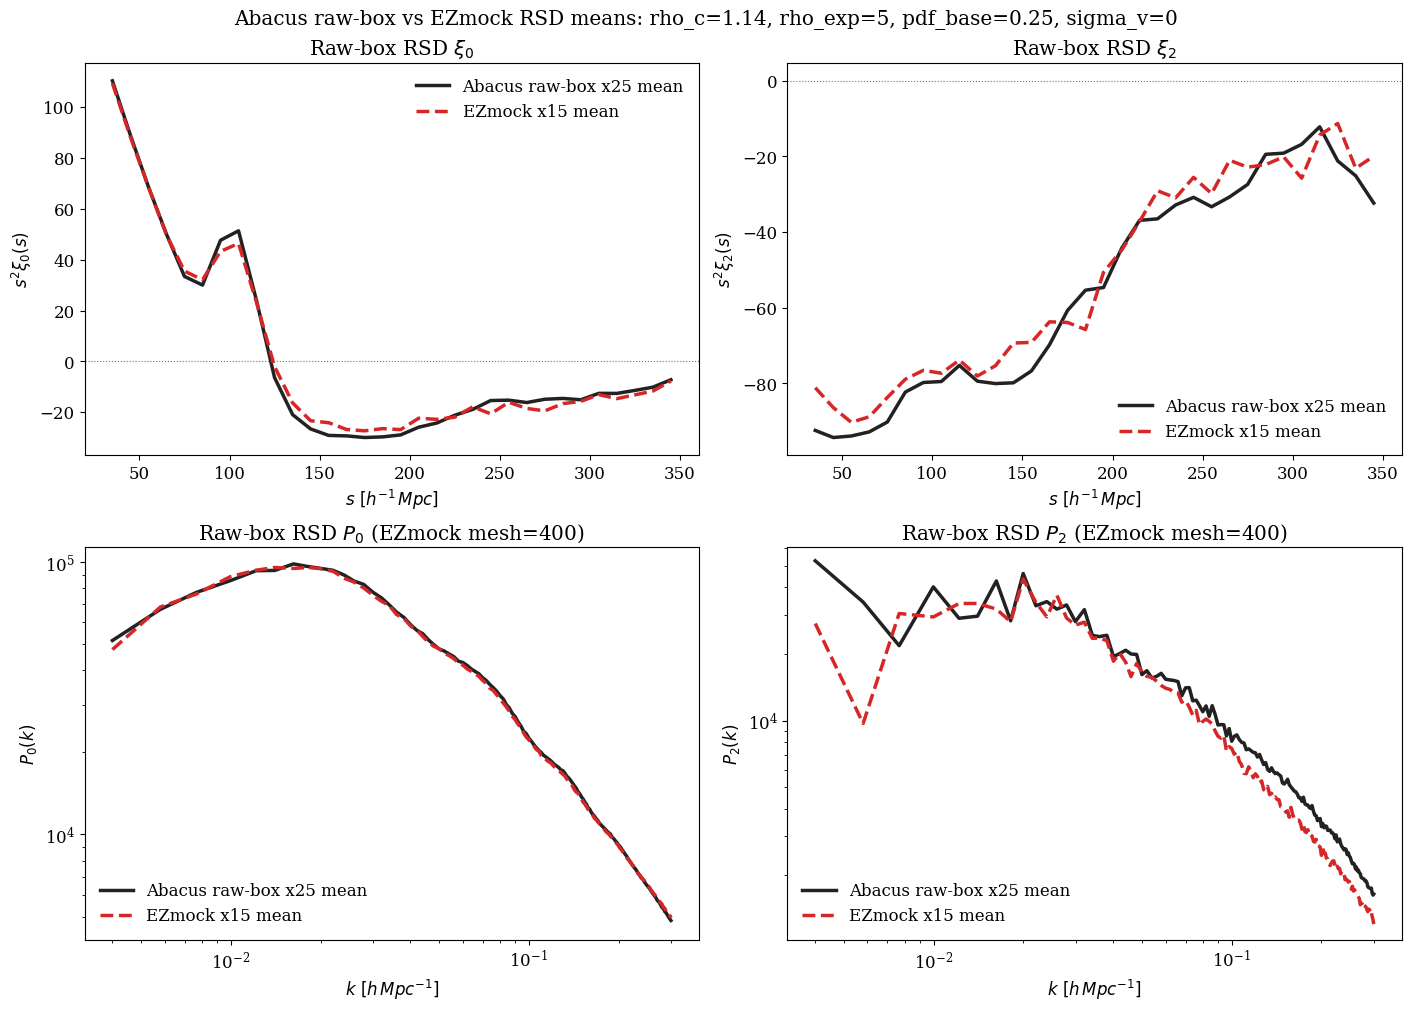

In [5]:
# ---------- Abacus raw-box mean vs EZmock mean ----------
# Only mean curves are shown so individual realizations do not clutter the plot
# or stretch the automatic y limits.
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# xi0
axes[0, 0].plot(
    abacus_target['s'], abacus_target['s']**2 * abacus_target['xi0_mean'],
    color='#222222', lw=2.5, label='Abacus raw-box x25 mean'
)
axes[0, 0].plot(
    s, s**2 * xi_mean[:, 0],
    color='#d62728', lw=2.5, ls='--', label=f'EZmock x{nreal} mean'
)
axes[0, 0].axhline(0, color='0.45', lw=0.8, ls=':')
axes[0, 0].set(
    xlabel=r'$s\ [h^{-1}\,Mpc]$', ylabel=r'$s^2\xi_0(s)$',
    title=r'Raw-box RSD $\xi_0$'
)
axes[0, 0].legend(frameon=False)

# xi2
axes[0, 1].plot(
    abacus_target['s'], abacus_target['s']**2 * abacus_target['xi2_mean'],
    color='#222222', lw=2.5, label='Abacus raw-box x25 mean'
)
axes[0, 1].plot(
    s, s**2 * xi_mean[:, 1],
    color='#d62728', lw=2.5, ls='--', label=f'EZmock x{nreal} mean'
)
axes[0, 1].axhline(0, color='0.45', lw=0.8, ls=':')
axes[0, 1].set(
    xlabel=r'$s\ [h^{-1}\,Mpc]$', ylabel=r'$s^2\xi_2(s)$',
    title=r'Raw-box RSD $\xi_2$'
)
axes[0, 1].legend(frameon=False)

# P0; each mean keeps its own k coordinate.
valid_abacus_p0 = np.isfinite(abacus_target['k']) & np.isfinite(abacus_target['pk0_mean'])
valid_ezmock_p0 = np.isfinite(k0) & np.isfinite(pk0_mean)
axes[1, 0].plot(
    abacus_target['k'][valid_abacus_p0], abacus_target['pk0_mean'][valid_abacus_p0],
    color='#222222', lw=2.5, label='Abacus raw-box x25 mean'
)
axes[1, 0].plot(
    k0[valid_ezmock_p0], pk0_mean[valid_ezmock_p0],
    color='#d62728', lw=2.5, ls='--', label=f'EZmock x{nreal} mean'
)
p0_visible = np.concatenate((
    abacus_target['pk0_mean'][valid_abacus_p0],
    pk0_mean[valid_ezmock_p0],
))
p0_visible = p0_visible[np.isfinite(p0_visible) & (p0_visible > 0.0)]
axes[1, 0].set(
    xscale='log', yscale='log', xlabel=r'$k\ [h\,Mpc^{-1}]$',
    ylabel=r'$P_0(k)$', title=f'Raw-box RSD $P_0$ (EZmock mesh={pk_mesh_size})'
)
axes[1, 0].set_ylim(0.85 * p0_visible.min(), 1.15 * p0_visible.max())
axes[1, 0].legend(frameon=False, loc='lower left')

# P2
valid_abacus_p2 = np.isfinite(abacus_target['k']) & np.isfinite(abacus_target['pk2_mean'])
valid_ezmock_p2 = np.isfinite(k0) & np.isfinite(pk2_mean)
axes[1, 1].plot(
    abacus_target['k'][valid_abacus_p2], abacus_target['pk2_mean'][valid_abacus_p2],
    color='#222222', lw=2.5, label='Abacus raw-box x25 mean'
)
axes[1, 1].plot(
    k0[valid_ezmock_p2], pk2_mean[valid_ezmock_p2],
    color='#d62728', lw=2.5, ls='--', label=f'EZmock x{nreal} mean'
)
p2_visible = np.concatenate((
    abacus_target['pk2_mean'][valid_abacus_p2],
    pk2_mean[valid_ezmock_p2],
))
p2_visible = p2_visible[np.isfinite(p2_visible)]
if np.all(p2_visible > 0.0):
    axes[1, 1].set(
        xscale='log', yscale='log', xlabel=r'$k\ [h\,Mpc^{-1}]$',
        ylabel=r'$P_2(k)$', title=f'Raw-box RSD $P_2$ (EZmock mesh={pk_mesh_size})'
    )
    axes[1, 1].set_ylim(0.85 * p2_visible.min(), 1.15 * p2_visible.max())
else:
    # Keep signed P2 visible if a trial parameter set produces both signs.
    p2_lo, p2_hi = p2_visible.min(), p2_visible.max()
    p2_pad = 0.15 * (p2_hi - p2_lo)
    axes[1, 1].set(
        xscale='log', yscale='symlog', xlabel=r'$k\ [h\,Mpc^{-1}]$',
        ylabel=r'$P_2(k)$', title=f'Raw-box RSD $P_2$ (EZmock mesh={pk_mesh_size})'
    )
    axes[1, 1].set_ylim(p2_lo - p2_pad, p2_hi + p2_pad)
axes[1, 1].legend(frameon=False, loc='lower left')

fig.suptitle(
    f'Abacus raw-box vs EZmock RSD means: rho_c={rho_c:g}, '
    f'rho_exp={rho_exp:g}, pdf_base={pdf_base:g}, sigma_v={sigma_v:g}'
)
plt.show()
